General-purpose SQD workflow for a Jordan-Wigner Pauli-list Hamiltonian file.
 
Nothing in this script is specific to any one molecule. Every physical quantity (qubit count, electron count, spin, reference energy, qubit ordering) is read from FILEPATH via parse_hamiltonian.parse_metadata(...) and parse_hamiltonian.parse_hamiltonian_file(...). To run this on a DIFFERENT Hamiltonian, you should only need to change FILEPATH below -- as long as that file follows the same header-comment conventions documented in parse_hamiltonian.py.
 
Uses qiskit-addon-sqd's generic qubit-Hamiltonian SQD routines (which work directly on a SparsePauliOp, unlike qiskit_addon_sqd.fermion which needs hcore/eri integrals we don't have access to here).

In [1]:
%pip install qiskit_addon_sqd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 112.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.6 MB/s eta 0:00:00


In [2]:
%pip install python-dotenv

In [3]:
%pip install qiskit_ibm_runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 10.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 14.3 MB/s eta 0:00:0000:01


In [4]:
from itertools import combinations
 
import matplotlib.pyplot as plt
import numpy as np
import qiskit_addon_sqd.configuration_recovery as sqd_cr
import qiskit_addon_sqd.counts as sqd_counts
import qiskit_addon_sqd.qubit as sqd_qubit
import qiskit_addon_sqd.subsampling as sqd_sub
from qiskit import QuantumCircuit
from qiskit.circuit.library import CPhaseGate, XXPlusYYGate
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from scipy.optimize import minimize
import math

In [5]:
import os

if not os.path.exists("SQD"):
    !git clone https://github.com/KhushiPandey1805/SQD.git SQD
    print("Cloned fresh.")
else:
    os.chdir("SQD")
    !git pull
    os.chdir("/content")
    print("Already present, pulled latest changes.")

!ls /content/SQD/code

import sys
sys.path.insert(0, "/content/SQD/code")

from hamiltonianCode import (
    interleaved_to_blocked_layout,
    parse_hamiltonian_file,
    parse_metadata,
)


Cloning into 'SQD'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 95 (delta 41), reused 75 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 528.51 KiB | 8.26 MiB/s, done.
Resolving deltas: 100% (41/41), done.
Cloned fresh.
hamiltonianCode.ipynb  hamiltonianCode.py  N2ex.ipynb  simVShardware.ipynb


In [ ]:
#only if pull fails earlier
#!rm /content/SQD/code/hamiltonianCode.py

In [ ]:
#only if pull failed and rm done
#%cd /content/SQD
#!git pull
#%cd /content

In [ ]:
# ----------------------------------------------------------------------
# ONLY THIS LINE SHOULD NEED TO CHANGE TO RUN A DIFFERENT HAMILTONIAN:
FILEPATH = "/content/SQD/hamiltonian/H2O_CAS4e4o_JW_Pauli_Hamiltonian_HERMITIAN.txt"
# ----------------------------------------------------------------------

Parse the file, remap to blocked ordering if needed, and return

(hamiltonian, metadata) where metadata also gets a few derived fields

(num_qubits, alpha_qubits, beta_qubits, hf_occupied_qubits) added.

In [9]:
def load_hamiltonian_and_metadata(filepath: str):
    hamiltonian = parse_hamiltonian_file(filepath)
    metadata = parse_metadata(filepath)
 
    norb = metadata["n_spatial_orbitals"]
    num_qubits = hamiltonian.num_qubits
    if num_qubits != 2 * norb:
        raise ValueError(
            f"Qubit count from file body ({num_qubits}) doesn't match "
            f"2 * n_spatial_orbitals from header ({2 * norb}). "
            "Double check the file isn't corrupted or using an unexpected format."
        )
 
    if metadata["qubit_ordering"] == "interleaved":
        layout = interleaved_to_blocked_layout(norb)
        hamiltonian = hamiltonian.apply_layout(layout, num_qubits=num_qubits).simplify()
    elif metadata["qubit_ordering"] == "blocked":
        pass  # already in the ordering qiskit-addon-sqd expects
    else:
        raise ValueError(
            "Could not determine qubit ordering ('interleaved' vs 'blocked') "
            "from the file header. Add explicit handling before proceeding -- "
            "using the wrong ordering here would silently corrupt the physics."
        )
 
    metadata["num_qubits"] = num_qubits
    metadata["alpha_qubits"] = list(range(norb))
    metadata["beta_qubits"] = list(range(norb, 2 * norb))
    metadata["hf_occupied_qubits"] = (
        list(range(metadata["n_alpha"])) + list(range(norb, norb + metadata["n_beta"]))
    )
 
    return hamiltonian, metadata

In [ ]:
def build_ansatz(params: np.ndarray, meta: dict, rot_pairs, jastrow_pairs, measure: bool) -> QuantumCircuit:
    """Hartree-Fock reference + [orbital rotation] + [Jastrow] + [orbital rotation]."""
    qc = QuantumCircuit(meta["num_qubits"])
    for q in meta["hf_occupied_qubits"]:
        qc.x(q)
 
    idx = 0
    for a, b in rot_pairs:
        qc.append(XXPlusYYGate(params[idx], params[idx + 1]), [a, b])
        idx += 2
    for a, b in jastrow_pairs:
        qc.append(CPhaseGate(params[idx]), [a, b])
        idx += 1
    for a, b in rot_pairs:
        qc.append(XXPlusYYGate(params[idx], params[idx + 1]), [a, b])
        idx += 2
 
    if measure:
        qc.measure_all()
    return qc

Classically optimize the ansatz against the exact Hamiltonian, as a stand-in for CCSD-amplitude seeding (which needs hcore/eri we don't have).

In [11]:
def optimize_ansatz(hamiltonian, meta, rot_pairs, jastrow_pairs, n_params, seed=7, maxiter=2000):
    estimator = StatevectorEstimator()
 
    def energy(params):
        qc = build_ansatz(params, meta, rot_pairs, jastrow_pairs, measure=False)
        return float(estimator.run([(qc, hamiltonian)]).result()[0].data.evs)
 
    rng = np.random.default_rng(seed)
    x0 = rng.normal(scale=0.3, size=n_params)
    return minimize(energy, x0, method="COBYLA", options={"maxiter": maxiter, "rhobeg": 0.5})

In [16]:
def run_sqd_workflow(hamiltonian, meta, sampler, circuit, shots: int, n_iterations: int = 5,
                      samples_per_batch: int = 20, num_batches: int = 3, label: str = "run"):
    """Sample -> recover -> batch -> diagonalize -> repeat. Works with either
    a noiseless StatevectorSampler or a real-hardware SamplerV2."""
    norb = meta["n_spatial_orbitals"]
    n_alpha, n_beta = meta["n_alpha"], meta["n_beta"]
    num_qubits = meta["num_qubits"]
 
    job = sampler.run([circuit], shots=shots)
    
    bit_array = job.result()[0].data.meas
    bitstring_matrix, probs = sqd_counts.bit_array_to_arrays(bit_array)
    print(f"[{label}] unique sampled bitstrings: {bitstring_matrix.shape[0]}")

    full_hilbert_space = 2 ** num_qubits
    correct_sector_size = math.comb(norb, n_alpha) * math.comb(norb, n_beta)
    print(f"[{label}] full Hilbert space size: {full_hilbert_space}")
    print(f"[{label}] correct-particle-number sector size: {correct_sector_size}")
    print(f"[{label}] unique configurations actually sampled: {bitstring_matrix.shape[0]}")

    bs_raw_valid, probs_raw_valid = sqd_sub.postselect_by_hamming_right_and_left(
        bitstring_matrix, probs, hamming_right=n_alpha, hamming_left=n_beta,
    )
    print(f"[{label}] fraction of shots retained (valid, before recovery): {probs_raw_valid.sum():.4f}")

    valid_count = sum(
    1 for row in bitstring_matrix
    if row[:norb].sum() == n_beta and row[norb:].sum() == n_alpha
    )
    print(f"Manually verified: {valid_count} valid out of {len(bitstring_matrix)} unique rows")
    print(f"Manually verified fraction (unweighted by shot count): {valid_count/len(bitstring_matrix):.4f}")
 
    # Hartree-Fock initial guess: lowest n_alpha/n_beta orbitals occupied
    avg_occ_a = np.array([1.0] * n_alpha + [0.0] * (norb - n_alpha))
    avg_occ_b = np.array([1.0] * n_beta + [0.0] * (norb - n_beta))
 
    energy_history = []
    for it in range(n_iterations):
        bs_recovered, probs_recovered = sqd_cr.recover_configurations(
            bitstring_matrix, probs, (avg_occ_a, avg_occ_b),
            num_elec_a=n_alpha, num_elec_b=n_beta, rand_seed=it,
        )
        bs_post, probs_post = sqd_sub.postselect_by_hamming_right_and_left(
            bs_recovered, probs_recovered, hamming_right=n_alpha, hamming_left=n_beta,
        )
        batches = sqd_sub.subsample(
            bs_post, probs_post, samples_per_batch=samples_per_batch,
            num_batches=num_batches, rand_seed=it,
        )
 
        best_energy, best_vec, best_bs = None, None, None
        for batch in batches:
            batch_sorted = sqd_qubit.sort_and_remove_duplicates(batch)
            eigvals, eigvecs = sqd_qubit.solve_qubit(batch_sorted, hamiltonian, k=1)
            if best_energy is None or eigvals[0] < best_energy:
                best_energy, best_vec, best_bs = eigvals[0], eigvecs[:, 0], batch_sorted
 
        weights = np.abs(best_vec) ** 2
        occ_by_array_column = (weights[:, None] * best_bs).sum(axis=0)
        occ_by_qubit = occ_by_array_column[::-1]  # array column j <-> qubit (N-1-j)
        avg_occ_a = occ_by_qubit[:norb]
        avg_occ_b = occ_by_qubit[norb:]
 
        energy_history.append(best_energy)
        error_mha = (best_energy - meta["reference_energy"]) * 1000
        print(f"[{label}] iter {it}: energy={best_energy:.6f}  error={error_mha:.3f} mHa")

        
    if label == "hardware":
        print(f"[{label}] QPU usage: {job.usage()} seconds")
 
    return energy_history

In [13]:
def plot_convergence(histories: dict, reference_energy: float, title: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    for label, history in histories.items():
        errors = [abs(e - reference_energy) for e in history]
        ax.plot(range(len(errors)), errors, marker="o", label=label)
    ax.axhline(y=0.0016, color="#BF5700", linestyle="--", label="chemical accuracy (~1.6 mHa)")
    ax.set_yscale("log")
    ax.set_xlabel("SQD iteration")
    ax.set_ylabel("Energy error vs. exact diagonalization (Ha)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig("sqd_convergence.png", dpi=150)
    print("Saved plot to sqd_convergence.png")

In [14]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager 
from getpass import getpass 

token = getpass("IBM Quantum API token: ") 
crn = getpass("CRN: ")

QiskitRuntimeService.save_account(
    token=token,
    instance=crn,
    overwrite=True,
    set_as_default=True
)

Loaded Hamiltonian: 8 qubits, 4 electrons (n_alpha=2, n_beta=2), reference energy=-76.11669094458742

Optimized ansatz energy: -76.103209  (error 13.482 mHa)

[simulator] unique sampled bitstrings: 20
[simulator] full Hilbert space size: 256
[simulator] correct-particle-number sector size: 36
[simulator] unique configurations actually sampled: 20
[simulator] fraction of shots retained (valid, before recovery): 1.0000
Manually verified: 20 valid out of 20 unique rows
Manually verified fraction (unweighted by shot count): 1.0000
[simulator] iter 0: energy=-76.113321  error=3.370 mHa
[simulator] iter 1: energy=-76.113321  error=3.370 mHa
[simulator] iter 2: energy=-76.113321  error=3.370 mHa
[simulator] iter 3: energy=-76.113321  error=3.370 mHa
[simulator] iter 4: energy=-76.113321  error=3.370 mHa
[hardware] unique sampled bitstrings: 255
[hardware] full Hilbert space size: 256
[hardware] correct-particle-number sector size: 36
[hardware] unique configurations actually sampled: 255
[har

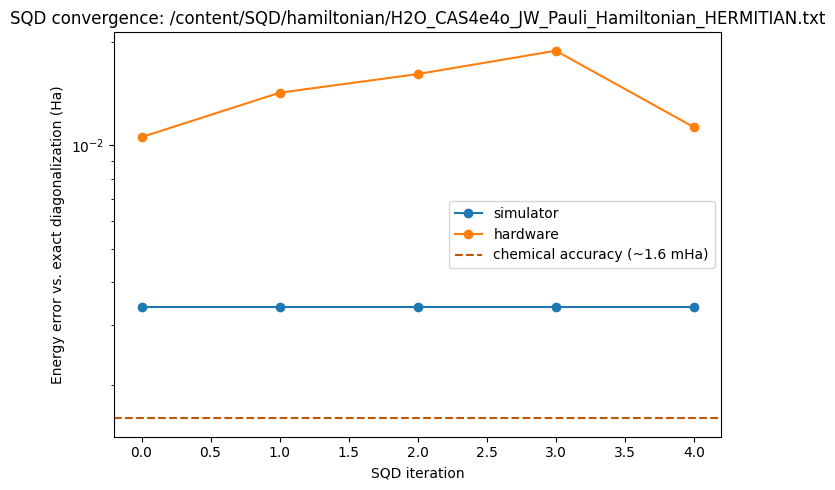

In [17]:
def main():
    hamiltonian, meta = load_hamiltonian_and_metadata(FILEPATH)
    print(f"Loaded Hamiltonian: {meta['num_qubits']} qubits, "
          f"{meta['n_electrons']} electrons "
          f"(n_alpha={meta['n_alpha']}, n_beta={meta['n_beta']}), "
          f"reference energy={meta['reference_energy']}\n")
 
    alpha_qubits, beta_qubits = meta["alpha_qubits"], meta["beta_qubits"]
    rot_pairs = list(combinations(alpha_qubits, 2)) + list(combinations(beta_qubits, 2))
    jastrow_pairs = list(combinations(range(meta["num_qubits"]), 2))
    n_params = 2 * len(rot_pairs) * 2 + len(jastrow_pairs)
 
    opt_result = optimize_ansatz(hamiltonian, meta, rot_pairs, jastrow_pairs, n_params)
    print(f"Optimized ansatz energy: {opt_result.fun:.6f}  "
          f"(error {((opt_result.fun - meta['reference_energy']) * 1000):.3f} mHa)\n")
 
    circuit = build_ansatz(opt_result.x, meta, rot_pairs, jastrow_pairs, measure=True)
 
    # ---------------- IDEAL / NOISELESS SIMULATOR ----------------
    sim_sampler = StatevectorSampler(seed=np.random.default_rng(0))
    sim_history = run_sqd_workflow(
        hamiltonian, meta, sim_sampler, circuit, shots=10_000, label="simulator"
    )
 
    # ---------------- REAL HARDWARE (uncomment once credentials are set) ----------------

    #""""

    service = QiskitRuntimeService(channel="ibm_quantum_platform")  # requires QiskitRuntimeService.save_account(...) once, beforehand
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=meta["num_qubits"])
    pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=2)
    isa_circuit = pass_manager.run(circuit)
    hw_sampler = SamplerV2(mode=backend)
    hw_history = run_sqd_workflow(
        hamiltonian, meta, hw_sampler, isa_circuit, shots=10_000, label="hardware"
        )
    plot_convergence({"simulator": sim_history, "hardware": hw_history},
                       meta["reference_energy"], title=f"SQD convergence: {FILEPATH}")

    #"""

    print("Total depth:", isa_circuit.depth())
    print("Two-qubit gate depth:", isa_circuit.depth(lambda instr: instr.operation.num_qubits == 2))
    print("Gate counts:", isa_circuit.count_ops())


    
 
 
if __name__ == "__main__":
    main()